# Imports y configuración

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

# Cargar Dataset

In [2]:
df = pd.read_csv("../data/raw/github_repositories.csv")

# Inspección inicial

In [3]:
df.head()

,repo_name,full_name,owner,stars,forks,watchers,open_issues,size,language,license,has_issues,has_projects,has_wiki,has_pages,archived,topics_count,description_length,created_at,updated_at,pushed_at,html_url,repo_age_days,days_since_update,stars_per_day,forks_to_stars_ratio
0,ML-For-Beginners,microsoft/ML-For-Beginners,microsoft,85813,20812,85813,7,2227898,Jupyter Notebook,MIT License,True,False,True,True,False,12,66,2021-03-03 01:34:05+00:00,2026-05-17 06:42:04+00:00,2026-05-08 23:43:14+00:00,https://github.com/microsoft/ML-For-Beginners,1901,0,45.117245,0.242525
1,superset,apache/superset,apache,72867,17315,72867,1265,944954,TypeScript,Apache License 2.0,True,True,True,True,False,18,69,2015-07-21 18:55:34+00:00,2026-05-17 05:26:47+00:00,2026-05-16 07:05:35+00:00,https://github.com/apache/superset,3952,0,18.433342,0.237621
2,scikit-learn,scikit-learn/scikit-learn,scikit-learn,66103,27026,66103,2022,182927,Python,"BSD 3-Clause ""New"" or ""Revised"" License",True,True,True,False,False,5,40,2010-08-17 09:43:38+00:00,2026-05-17 06:36:53+00:00,2026-05-16 15:53:37+00:00,https://github.com/scikit-learn/scikit-learn,5751,0,11.492177,0.408841
3,keras,keras-team/keras,keras-team,64072,19775,64072,187,53032,Python,Apache License 2.0,True,True,True,False,False,8,24,2015-03-28 00:35:42+00:00,2026-05-17 04:07:00+00:00,2026-05-16 01:55:29+00:00,https://github.com/keras-team/keras,4068,0,15.746375,0.308632
4,30-Days-Of-Python,Asabeneh/30-Days-Of-Python,Asabeneh,62659,11893,62659,123,30842,Python,NaN,True,True,True,False,False,15,270,2019-11-19 17:24:16+00:00,2026-05-17 06:39:52+00:00,2026-04-04 17:59:06+00:00,https://github.com/Asabeneh/30-Days-Of-Python,2370,0,26.427246,0.189802


In [4]:
df.shape

(1573, 25)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1573 entries, 0 to 1572
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   repo_name             1573 non-null   object 
 1   full_name             1573 non-null   object 
 2   owner                 1573 non-null   object 
 3   stars                 1573 non-null   int64  
 4   forks                 1573 non-null   int64  
 5   watchers              1573 non-null   int64  
 6   open_issues           1573 non-null   int64  
 7   size                  1573 non-null   int64  
 8   language              1368 non-null   object 
 9   license               1313 non-null   object 
 10  has_issues            1573 non-null   bool   
 11  has_projects          1573 non-null   bool   
 12  has_wiki              1573 non-null   bool   
 13  has_pages             1573 non-null   bool   
 14  archived              1573 non-null   bool   
 15  topics_count         

# Revisar valores nulos

In [6]:
nulls = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

nulls

license                 260
language                205
repo_name                 0
archived                  0
stars_per_day             0
days_since_update         0
repo_age_days             0
html_url                  0
pushed_at                 0
updated_at                0
created_at                0
description_length        0
topics_count              0
has_wiki                  0
has_pages                 0
full_name                 0
has_projects              0
has_issues                0
size                      0
open_issues               0
watchers                  0
forks                     0
stars                     0
owner                     0
forks_to_stars_ratio      0
dtype: int64

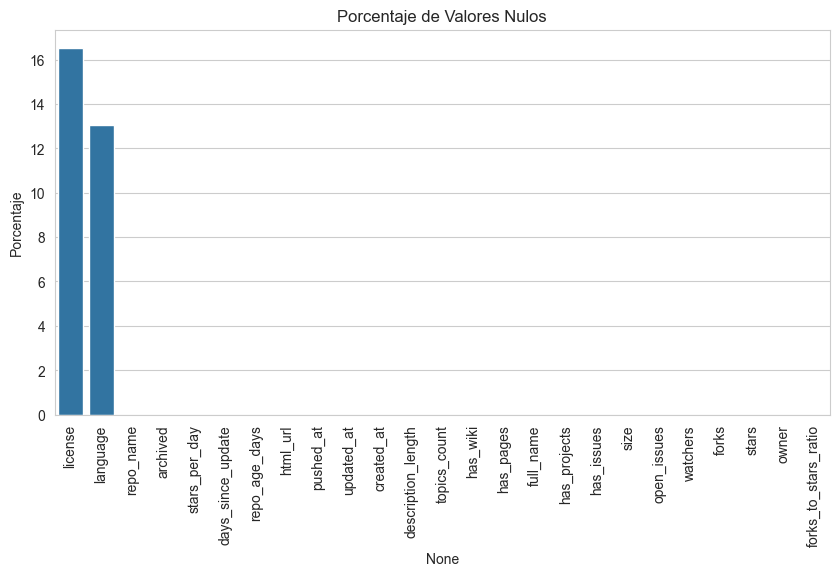

In [7]:
null_percentage = (
    df.isnull()
      .mean()
      * 100
).sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    x=null_percentage.index,
    y=null_percentage.values
)

plt.xticks(rotation=90)

plt.ylabel("Porcentaje")

plt.title("Porcentaje de Valores Nulos")

plt.show()

# Duplicados

In [8]:
df.duplicated().sum()

np.int64(0)

# Estadistica Descriptiva

In [9]:
df.describe()

,stars,forks,watchers,open_issues,size,topics_count,description_length,repo_age_days,days_since_update,stars_per_day,forks_to_stars_ratio
count,1573.000000,1573.000000,1573.000000,1573.000000,1.573000e+03,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000
mean,9780.996186,1847.127781,9780.996186,173.080737,1.982836e+05,9.987921,181.001907,2498.545455,2.381437,6.103665,0.191119
std,15622.612877,4005.862614,15622.612877,607.767581,1.400958e+06,6.107954,2288.284979,1184.549901,6.123991,15.243267,0.239701
min,686.000000,18.000000,686.000000,0.000000,0.000000e+00,0.000000,0.000000,26.000000,0.000000,0.142289,0.006424
25%,2433.000000,328.000000,2433.000000,9.000000,5.372000e+03,5.000000,50.000000,1554.000000,0.000000,1.100414,0.098745
50%,4520.000000,721.000000,4520.000000,41.000000,3.054500e+04,9.000000,75.000000,2571.000000,0.000000,2.336207,0.147195
75%,10372.000000,1877.000000,10372.000000,130.000000,1.217320e+05,15.000000,112.000000,3279.000000,2.000000,4.936039,0.222857
max,195130.000000,75305.000000,195130.000000,18498.000000,4.798441e+07,20.000000,64765.000000,6571.000000,95.000000,294.281853,7.529869


# Distribución de Stars

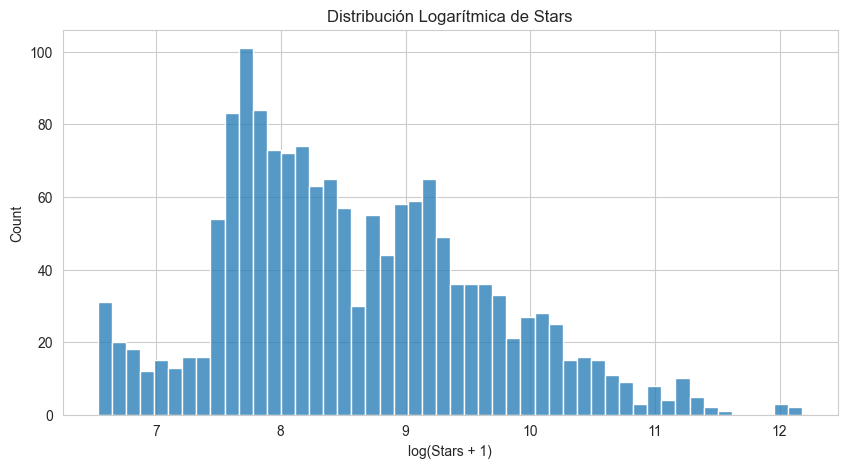

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(df["stars"]),
    bins=50
)

plt.title("Distribución Logarítmica de Stars")

plt.xlabel("log(Stars + 1)")

plt.show()

In [11]:
df["stars"].skew()

np.float64(5.396497720956968)

# Top Lenguajes

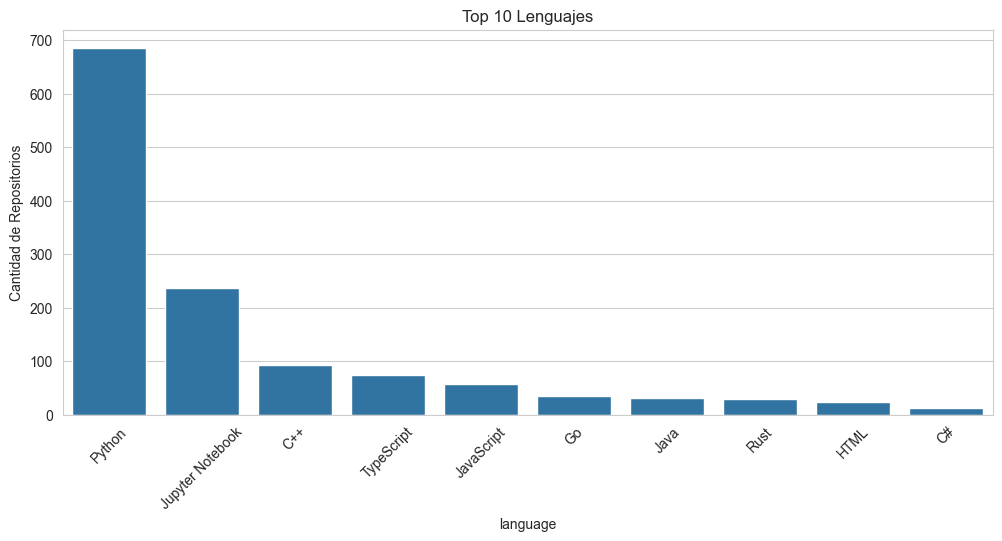

In [12]:
top_languages = (
    df["language"]
      .value_counts()
      .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_languages.index,
    y=top_languages.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Lenguajes")

plt.ylabel("Cantidad de Repositorios")

plt.show()

# Correlaciones

In [13]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

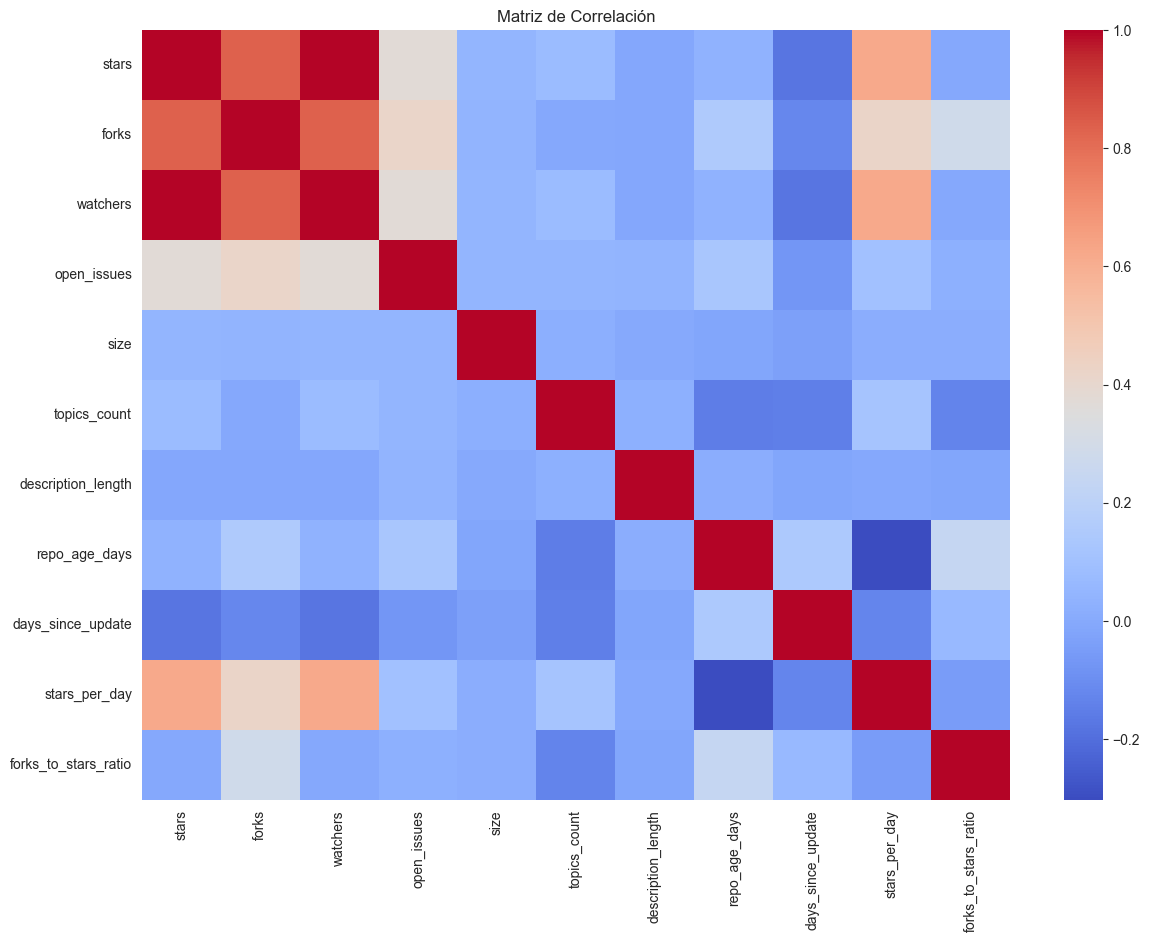

In [14]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Matriz de Correlación")

plt.show()

# Relaciones Importantes

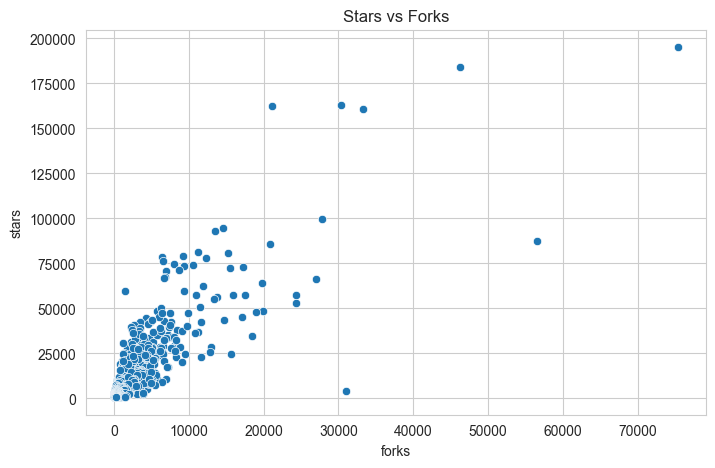

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="forks",
    y="stars"
)

plt.title("Stars vs Forks")

plt.show()

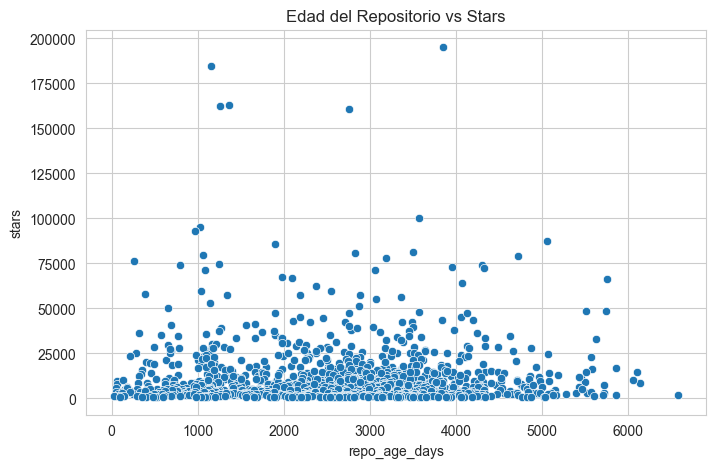

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="repo_age_days",
    y="stars"
)

plt.title("Edad del Repositorio vs Stars")

plt.show()

# Boxplots

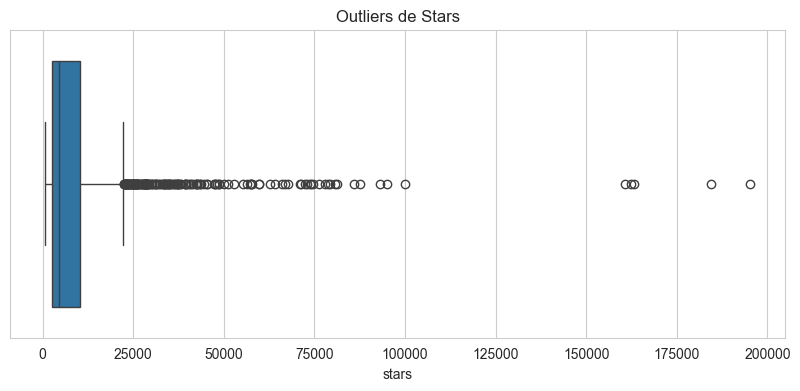

In [17]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["stars"])

plt.title("Outliers de Stars")

plt.show()

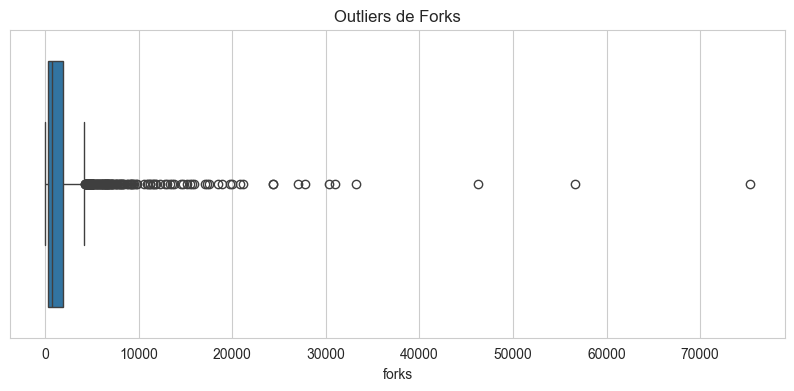

In [18]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["forks"])

plt.title("Outliers de Forks")

plt.show()

# Analisis Temporal

In [19]:
df["created_at"] = pd.to_datetime(df["created_at"])

repos_per_year = (
    df["created_at"]
      .dt.year
      .value_counts()
      .sort_index()
)

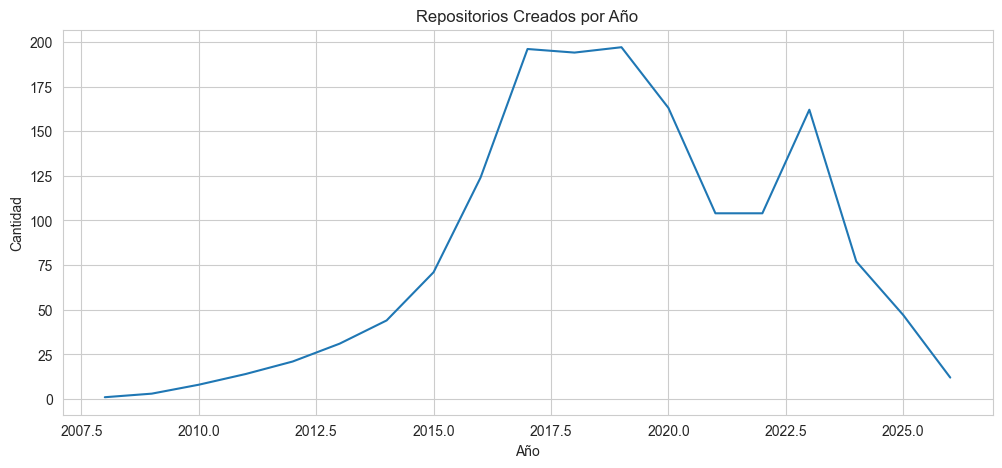

In [20]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=repos_per_year.index,
    y=repos_per_year.values
)

plt.title("Repositorios Creados por Año")

plt.xlabel("Año")

plt.ylabel("Cantidad")

plt.show()

# Booleanos

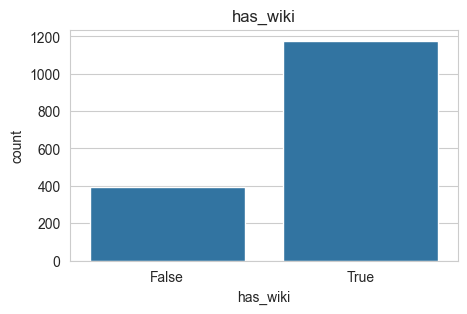

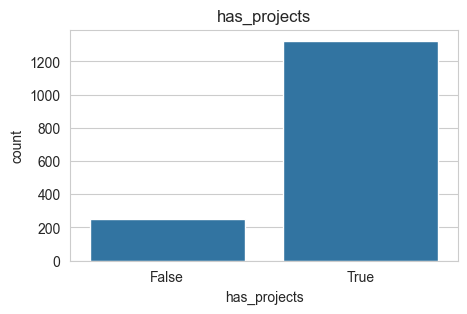

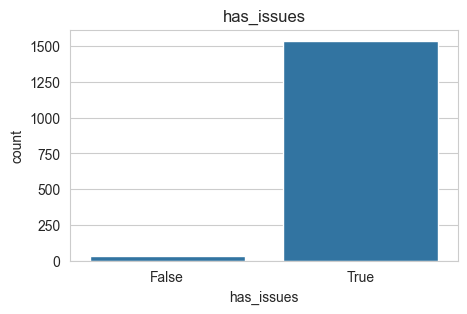

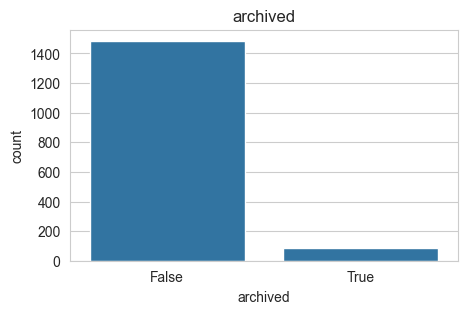

In [21]:
boolean_cols = [
    "has_wiki",
    "has_projects",
    "has_issues",
    "archived"
]

for col in boolean_cols:

    plt.figure(figsize=(5,3))

    sns.countplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

# Hallazgos del Análisis Exploratorio de Datos (EDA)

## 1. Distribución de Popularidad (Stars)

La variable `stars` presenta una distribución altamente asimétrica positiva, evidenciando una fuerte concentración de repositorios con popularidad moderada y un pequeño grupo de repositorios extremadamente populares.

La transformación logarítmica aplicada (`log(stars + 1)`) permitió reducir significativamente la asimetría y visualizar de mejor manera la distribución subyacente de los datos. Este comportamiento es característico de plataformas open source, donde pocos proyectos concentran gran parte de la atención y adopción comunitaria.

Adicionalmente, la presencia de numerosos outliers indica que existen proyectos con una popularidad excepcionalmente alta, lo cual sugiere dinámicas de crecimiento no lineales dentro del ecosistema de Ciencia de Datos.

---

## 2. Lenguajes de Programación Dominantes

Python domina ampliamente el conjunto de datos, representando una proporción significativamente mayor que cualquier otro lenguaje de programación.

Este hallazgo es consistente con la adopción masiva de Python en:
- Machine Learning,
- Inteligencia Artificial,
- Deep Learning,
- análisis de datos,
- y desarrollo científico.

También se observa una presencia importante de:
- Jupyter Notebook,
- C++,
- TypeScript,
- JavaScript.

La aparición de C++ y Rust sugiere la existencia de proyectos enfocados en rendimiento computacional y optimización de infraestructura para modelos de IA.

---

## 3. Correlaciones Entre Variables

La matriz de correlación muestra una fuerte relación positiva entre:
- `stars`,
- `forks`,
- y `watchers`.

Esto sugiere que la participación comunitaria y la visibilidad pública están estrechamente relacionadas dentro del ecosistema open source.

En particular:
- los repositorios con mayor número de forks tienden a recibir más estrellas,
- y los proyectos ampliamente observados por la comunidad suelen alcanzar altos niveles de popularidad.

Asimismo, la variable `stars_per_day` presenta correlaciones relevantes con las métricas de popularidad, indicando que la velocidad de crecimiento de un proyecto constituye un indicador importante de adopción tecnológica.

Por otro lado, variables como:
- `size`,
- `description_length`,
- y `topics_count`

muestran correlaciones débiles con la popularidad, lo que sugiere que el tamaño técnico del proyecto no necesariamente determina su éxito comunitario.

---

## 4. Relación entre Stars y Forks

El análisis de dispersión entre `stars` y `forks` evidencia una tendencia positiva clara.

Los repositorios más populares suelen presentar también altos niveles de reutilización y contribución comunitaria.

Sin embargo, se observan ciertos outliers con:
- muchos forks pero relativamente pocas estrellas,
- o alta popularidad con menor nivel de bifurcación.

Esto podría indicar diferentes tipos de proyectos:
- repositorios educativos,
- librerías base altamente reutilizadas,
- o proyectos experimentales ampliamente compartidos.

---

## 5. Antigüedad del Repositorio y Popularidad

La relación entre `repo_age_days` y `stars` muestra que la antigüedad del proyecto no garantiza automáticamente una mayor popularidad.

Aunque algunos repositorios antiguos concentran grandes cantidades de estrellas, también existen proyectos relativamente recientes que han alcanzado altos niveles de adopción en períodos cortos.

Este comportamiento sugiere que:
- la actividad reciente,
- la relevancia tecnológica,
- y las tendencias de la comunidad

pueden influir más significativamente que la antigüedad del repositorio.

---

## 6. Outliers y Concentración de Popularidad

Los boxplots de `stars` y `forks` evidencian una gran cantidad de valores atípicos.

Esto confirma la existencia de una estructura de tipo “long tail” en el ecosistema open source:
- pocos proyectos concentran enormes cantidades de interacción,
- mientras la mayoría mantiene niveles moderados de actividad y popularidad.

La existencia de estos outliers justifica:
- el uso de transformaciones logarítmicas,
- modelos robustos,
- y técnicas de reducción de dimensionalidad en etapas posteriores del análisis.

---

## 7. Evolución Temporal de los Repositorios

El análisis temporal muestra un crecimiento acelerado en la creación de repositorios relacionados con Ciencia de Datos entre 2015 y 2020.

Este comportamiento coincide con:
- la expansión de Deep Learning,
- la popularización de frameworks como TensorFlow y PyTorch,
- y el crecimiento global de aplicaciones de Inteligencia Artificial.

Se observa además una ligera disminución en años recientes, posiblemente relacionada con:
- repositorios aún emergentes,
- menor tiempo de acumulación de estrellas,
- o cambios en las tendencias de desarrollo open source.

---

## 8. Características de Gestión de Repositorios

La mayoría de los repositorios analizados:
- poseen wiki habilitada,
- utilizan GitHub Projects,
- y mantienen el sistema de issues activo.

Esto sugiere que los proyectos más relevantes del ecosistema suelen incorporar herramientas formales de colaboración y mantenimiento comunitario.

Asimismo, la baja proporción de repositorios archivados indica que gran parte del dataset corresponde a proyectos aún activos o mantenidos recientemente.

---

## 9. Hallazgos Generales

El análisis exploratorio permite concluir preliminarmente que el éxito de un repositorio de Ciencia de Datos parece estar más relacionado con:
- la interacción comunitaria,
- la actividad de mantenimiento,
- y la capacidad de difusión tecnológica,

que con factores puramente estructurales como el tamaño del código o la longitud de la documentación.

Estos resultados justifican la aplicación posterior de modelos predictivos con el objetivo de identificar patrones latentes y factores asociados al éxito de proyectos open source.